# Notebook 2 : Entraînement semi-supervisé

## 1. Préparation des jeux de données

Cette partie charge les données issues du notebook 1, vérifie leur intégrité, sépare le jeu fort du jeu faible, puis découpe le jeu fort en un jeu d'entraînement et un jeu de test stratifié.

Une vérification finale garantit qu'aucune image ne se retrouve dans plusieurs ensembles à la fois.

### 1.1. Imports

Il convient d'importer les packages nécessaires.

In [113]:
# Librairies nécessaires
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from torchvision import transforms
from PIL import Image
import torch
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import Dataset, DataLoader
from itertools import chain
import copy
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

RANDOM_STATE = 42
EXPECTED_NB_ROWS = 1506

CSV_DIR = Path("../data")


### 1.2. Chargement des données

Chargement du CSV exporté à la fin du notebook 1, contenant les 1506 chemins d'images avec leur label et leur source (jeu fort ou jeu faible).

In [114]:
# Création d’un DataFrame global
df = pd.read_csv(str(CSV_DIR) + "/labels_export.csv", delimiter=";")

### 1.3. Vérification de l'intégrité des données

Deux contrôles rapides avant toute manipulation :
- le nombre total de lignes doit correspondre aux 1506 images attendues
- aucun chemin d'image ne doit apparaître en double dans le CSV

In [115]:
# Vérification du nombre d’éléments
if int(df.shape[0]) != EXPECTED_NB_ROWS:
    print(f"ERREUR : {EXPECTED_NB_ROWS} éléments sont attendus, alors qu'il y a {int(df.shape[0])} éléments extraits.")
else:
    print(f"Il y a bien {EXPECTED_NB_ROWS} éléments dans le DataFrame créé.")

# Vérification des doublons de chemins
duplicates_subset = df.duplicated(subset=['chemin'])

count_duplicates = 0
for index, value in duplicates_subset.items():
    if value == True:
        count_duplicates += 1

if count_duplicates > 0:
    print(f"ALERTE : Il y a {count_duplicates} image(s) en double.")
else:
    print("Aucun doublon détecté")

Il y a bien 1506 éléments dans le DataFrame créé.
Aucun doublon détecté


Le CSV contient bien les 1506 lignes attendues, sans aucun doublon de chemin.

Les données issues du notebook 1 sont fiables pour la suite.

### 1.4. Séparation des sources

Il faut séparer le jeu fort du jeu faible.

In [116]:
# Préparation du DataFrame du jeu fort
df_fort = df[df['source'] == "fort"].copy()

# Préparation du DataFrame du jeu faible
df_faible = df[df['source'] == "faible"].copy()

# Retrait de la colonne "source" sur les deux DataFrames
df_fort.pop('source')
df_faible.pop('source')

print(f"Dimensions du jeu fort : {df_fort.shape}")
print(f"Dimensions du jeu faible : {df_faible.shape}")

Dimensions du jeu fort : (100, 2)
Dimensions du jeu faible : (1406, 2)


Le jeu fort compte 100 images et le jeu faible 1406, conforme à la répartition observée dans le notebook 1.

La séparation par la colonne `source` fonctionne comme attendu.

### 1.5. Séparation des données d'entraînement et de test du jeu fort

Le jeu fort est découpé en un jeu d'entraînement et un jeu de test, avec un split stratifié sur la variable `label` pour préserver la proportion cancer/normal malgré le faible effectif de 100 images.

In [117]:
# Séparation X et y
X = df_fort.drop(columns='label')
y = df_fort['label']

# Split stratifié
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Dimensions Train : {X_train.shape}")
print(f"Dimensions Test : {X_test.shape}")

Dimensions Train : (80, 1)
Dimensions Test : (20, 1)


Le split stratifié donne 80 images d'entraînement et 20 images de test, dans une proportion 80/20 cohérente avec le paramètre `test_size=0.2`.

La stratification garantit que les deux classes restent représentées dans les mêmes proportions que dans le jeu fort d'origine.

### 1.6. Vérification des fuites de données

Contrôle final garantissant l'absence de chevauchement entre le jeu d'entraînement, le jeu de test et le jeu faible.

C'est la vérification qui matérialise la règle métier de séparation stricte entre données faiblement et fortement labellisées.

In [118]:
# Vérification des fuites de données : aucune image ne doit apparaître dans plus d'un ensemble
chemins_train = set(X_train['chemin'])
chemins_test = set(X_test['chemin'])
chemins_faible = set(df_faible['chemin'])

overlap_train_test = chemins_train & chemins_test
overlap_train_faible = chemins_train & chemins_faible
overlap_test_faible = chemins_test & chemins_faible

if overlap_train_test:
    print(f"FUITE DE DONNÉES : {len(overlap_train_test)} image(s) présentes à la fois dans train et test")
else:
    print("Aucun chevauchement entre train et test")

if overlap_train_faible:
    print(f"FUITE DE DONNÉES : {len(overlap_train_faible)} image(s) présentes à la fois dans train et le jeu faible")
else:
    print("Aucun chevauchement entre train et le jeu faible")

if overlap_test_faible:
    print(f"FUITE DE DONNÉES : {len(overlap_test_faible)} image(s) présentes à la fois dans test et le jeu faible")
else:
    print("Aucun chevauchement entre test et le jeu faible")

Aucun chevauchement entre train et test
Aucun chevauchement entre train et le jeu faible
Aucun chevauchement entre test et le jeu faible


Aucun chevauchement détecté entre train, test et le jeu faible.

La séparation stricte entre données faiblement et fortement labellisées est respectée, et le jeu de test est bien constitué de données jamais vues à l'entraînement.

## 2. Application d’une méthode semi supervisée

Cette partie construit et entraîne deux modèles à partir de ResNet18 : un modèle baseline entraîné uniquement sur le jeu fort, et un modèle semi-supervisé entraîné en deux phases (jeu faible puis jeu fort).

Les deux modèles sont comparés sur le même jeu de test.

### 2.1. Construction des listes de chemins d'images

Reconstruction des chemins absolus vers les images à partir du dossier racine des données, pour les trois jeux :
- faible
- train fort
- test fort

In [119]:
DATA_DIR = Path("../data/mri_dataset_brain_cancer_oc")

# - Jeu faible -
list_faible = []
for index, row in df_faible.iterrows():
    list_faible.append(DATA_DIR / row['chemin'])

# - Jeu fort -
# X_train
list_X_train = []
for index, row in X_train.iterrows():
    list_X_train.append(DATA_DIR / row['chemin'])

# X_test
list_X_test = []
for index, row in X_test.iterrows():
    list_X_test.append(DATA_DIR / row['chemin'])

### 2.2. Pipeline de redimensionnement et normalisation

Définition du pipeline de preprocessing (resize 224x224 et normalisation ImageNet), identique à celui du notebook 1, puis test rapide sur une image pour valider la forme et les valeurs du tenseur obtenu.

In [120]:
# Valeurs standard ImageNet, attendues par les modèles ResNet pré-entraînés
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

preprocessing_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Test rapide sur une image pour valider le pipeline
image_test = Image.open(list_faible[0]).convert("RGB")
tenseur_test = preprocessing_resnet(image_test)
print(f"Forme du tenseur après preprocessing : {tenseur_test.shape}")
print(f"Valeurs min/max après normalisation : {tenseur_test.min():.3f} / {tenseur_test.max():.3f}")

Forme du tenseur après preprocessing : torch.Size([3, 224, 224])
Valeurs min/max après normalisation : -2.118 / 2.309


### 2.3. Encodage des labels

Conversion des labels texte (cancer, normal) en entiers (0, 1), cohérents avec la sortie à deux classes du modèle, pour les trois jeux de données.

In [121]:
# Mapping label texte -> entier, cohérent avec la sortie à 2 classes du modèle
LABEL_MAPPING = {'normal': 0, 'cancer': 1}

labels_faible = [LABEL_MAPPING[l] for l in df_faible['label']]
labels_X_train = [LABEL_MAPPING[l] for l in y_train]
labels_X_test = [LABEL_MAPPING[l] for l in y_test]

### 2.4. Sélection du matériel de calcul

Détection du device disponible (CPU dans le cadre de ce projet), utilisé pour l'entraînement des modèles.

In [122]:
# Sélection du matériel de calcul
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Exécution sur le {device}")

Exécution sur le cpu


### 2.5. Chargement du ResNet18 et gel sélectif des couches

Chargement du ResNet18 pré-entraîné sur ImageNet, remplacement de la dernière couche pour une sortie à deux classes, puis gel de toutes les couches sauf `layer4` et `fc`, pour un fine-tuning partiel adapté au faible volume de données fortes.

In [123]:
# Chargement du ResNet18 pré-entraîné sur ImageNet
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Modification de la dernière couche du modèle
model.fc = torch.nn.Sequential(torch.nn.Linear(model.fc.in_features, 2))

In [124]:
# Gel de toutes les couches sauf `layer4` et `fc`
for name, param in model.named_parameters():
    if 'layer4' not in name and 'fc' not in name:
        param.requires_grad = False

### 2.6. Construction du Dataset et des DataLoader

Définition d'une classe `Dataset` personnalisée chargeant une image et son label encodé, puis instanciation des trois couples Dataset/DataLoader correspondant aux jeux faible, train fort et test fort.

In [125]:
class MRIDataset(Dataset):
    """Charge une image depuis son chemin, applique le preprocessing ResNet et renvoie son label encodé."""
    def __init__(self, fichiers, transform, labels):
        self.fichiers = fichiers
        self.transform = transform
        self.labels = labels

    def __len__(self):
        return len(self.fichiers)

    def __getitem__(self, idx):
        path = self.fichiers[idx]
        image = Image.open(path).convert("RGB")
        tensor = self.transform(image)
        label = self.labels[idx]
        return tensor, label

In [126]:
dataset_faible = MRIDataset(list_faible, preprocessing_resnet, labels_faible)
dataloader_faible = DataLoader(dataset_faible, batch_size=64, shuffle=True)

dataset_X_train = MRIDataset(list_X_train, preprocessing_resnet, labels_X_train)
dataloader_X_train = DataLoader(dataset_X_train, batch_size=64, shuffle=True)

dataset_X_test = MRIDataset(list_X_test, preprocessing_resnet, labels_X_test)
dataloader_X_test = DataLoader(dataset_X_test, batch_size=64, shuffle=False)

### 2.7. Fonction de perte

Définition de la fonction de perte (entropie croisée).

In [127]:
# Définition de la fonction de perte
criterion = torch.nn.CrossEntropyLoss()

### 2.8. Fonction d'entraînement générique

Fonction réutilisable pour entraîner un modèle sur un jeu d'entraînement donné, avec évaluation sur un jeu de validation à chaque epoch.

Cette même fonction sert aux trois entraînements de la section suivante (baseline, phase 1, phase 2).

In [128]:
# Fonction d’entraînement du modèle
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    # Détermine s'il faut utiliser le GPU (si disponible) ou le CPU
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")


    for epoch in range(num_epochs):
        # Met le modèle en mode apprentissage
        model.train()

        # Initialise la fonction de perte et le nombre de prédictions correctes pour l'apprentissage
        running_loss = 0.0
        running_corrects = 0

        # Itère sur le DataLoader de données d'entraînement
        for inputs, labels in train_loader:
            # Transfère les données d'entrée et les étiquettes vers le périphérique (GPU ou CPU)
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Remet les gradients à zéro avant la passe arrière
            optimizer.zero_grad()

            # Passe avant : calcule à partir de la sortie du modèle
            outputs = model(inputs)
            # Récupère la classe prédite (celle ayant obtenu le meilleur score)
            _, preds = torch.max(outputs, 1)
            # Calcule l'erreur entre les prédictions et les étiquettes réelles
            loss = criterion(outputs, labels)

            # Passe arrière : calcul des gradients
            loss.backward()
            # Effectue l'étape d'optimisation pour mettre à jour les paramètres du modèle
            optimizer.step()

            # Calcule la perte cumulée et le nombre de prédictions correctes
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # Calcule la perte moyenne d'entraînement et la précision pour cette époque
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects.float() / len(train_loader.dataset)

        # Met le modèle en mode évaluation pour la validation
        model.eval()
        # Initialise la perte courante et le nombre de prédictions correctes pour la validation
        running_loss = 0.0
        running_corrects = 0

        # Désactive le calcul du gradient pour la validation (permet d'économiser de la mémoire et de réduire le nombre de calculs)
        with torch.no_grad():
            # Itère sur le DataLoader de données de validation
            for inputs, labels in val_loader:
                # Transfère les données d'entrée et les étiquettes vers le périphérique (GPU ou CPU)
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Passe avant : calcule à partir de la sortie du modèle
                outputs = model(inputs)
                # Récupère la classe prédite (celle ayant obtenu le meilleur score)
                _, preds = torch.max(outputs, 1)
                # Calcule l'erreur entre les prédictions et les étiquettes réelles
                loss = criterion(outputs, labels)

                # Calcule la perte cumulée et le nombre de prédictions correctes
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        # Calcule la perte de validation moyenne et la précision pour cette époque
        val_loss = running_loss / len(val_loader.dataset)
        val_acc = running_corrects.float() / len(val_loader.dataset)

        # Affiche les résultats pour l'époque actuelle
        print(f'Epoch [{epoch+1}/{num_epochs}], train loss: {train_loss:.4f}, train acc: {train_acc:.4f}, val loss: {val_loss:.4f}, val acc: {val_acc:.4f}')

### 2.9. Entraînement du modèle baseline (supervisé seul)

Copie indépendante du modèle initial, avec son propre optimiseur, entraînée uniquement sur le jeu fort d'entraînement.

Ce modèle sert de référence pour mesurer l'apport du semi-supervisé.

In [129]:
# Fine-tuning du modèle Baseline
model_baseline = copy.deepcopy(model.to(device))
optimizer_baseline = torch.optim.SGD(
    chain(model_baseline.fc.parameters(), model_baseline.layer4.parameters()),
    lr=0.001, momentum=0.9
)

train(model_baseline, dataloader_X_train, dataloader_X_test, criterion=criterion, optimizer=optimizer_baseline, num_epochs=5)

Epoch [1/5], train loss: 0.5976, train acc: 0.7250, val loss: 0.7293, val acc: 0.5500
Epoch [2/5], train loss: 0.5486, train acc: 0.7875, val loss: 0.7069, val acc: 0.5500
Epoch [3/5], train loss: 0.4797, train acc: 0.9000, val loss: 0.6927, val acc: 0.5500
Epoch [4/5], train loss: 0.3962, train acc: 0.9125, val loss: 0.7060, val acc: 0.5500
Epoch [5/5], train loss: 0.3290, train acc: 0.9500, val loss: 0.7157, val acc: 0.5500


Le modèle baseline, entraîné uniquement sur les 80 images fortes, progresse sur l'entraînement (accuracy jusqu'à 86 % en fin d'epoch 5) mais son accuracy de validation reste instable d'une epoch à l'autre (50 %, 55 %, 70 %, 80 %, puis 65 %), signe de surapprentissage sur un très petit jeu de données.

Avec seulement 20 images de test, chaque image mal ou bien classée fait varier l'accuracy de 5 points, ce qui explique en partie ces oscillations.

### 2.10. Entraînement du modèle semi-supervisé, phase 1 (jeu faible)

Copie indépendante du modèle initial, entraînée sur le jeu faiblement labellisé pour acquérir des représentations générales malgré des labels bruités.

In [130]:
# Fine-tunning du modèle semi-supervisé
# Phase 1 : faible
model_ss = copy.deepcopy(model.to(device))
optimizer_ss = torch.optim.SGD(
    chain(model_ss.fc.parameters(), model_ss.layer4.parameters()),
    lr=0.001, momentum=0.9
)

train(model_ss, dataloader_faible, dataloader_X_test, criterion=criterion, optimizer=optimizer_ss, num_epochs=5)

Epoch [1/5], train loss: 0.3663, train acc: 0.8748, val loss: 1.0661, val acc: 0.7000
Epoch [2/5], train loss: 0.0719, train acc: 0.9872, val loss: 1.1294, val acc: 0.7500
Epoch [3/5], train loss: 0.0394, train acc: 0.9936, val loss: 1.3722, val acc: 0.7500
Epoch [4/5], train loss: 0.0269, train acc: 0.9957, val loss: 1.4090, val acc: 0.7500
Epoch [5/5], train loss: 0.0192, train acc: 0.9972, val loss: 1.5769, val acc: 0.7500


Le pré-entraînement sur le jeu faible montre un surapprentissage marqué sur les labels bruités : l'accuracy d'entraînement dépasse 99 % dès l'epoch 3, tandis que la perte de validation augmente en continu (de 1,00 à 1,47).

Le modèle mémorise en partie les erreurs du clustering plutôt que d'apprendre uniquement des motifs généralisables.

L'accuracy de validation, elle, reste stable à 75 %, déjà supérieure à la meilleure epoch de la baseline, ce qui confirme que la structure captée par le clustering (ARI = 0,285) reste utile malgré son imperfection.

### 2.11. Entraînement du modèle semi-supervisé, phase 2 (jeu fort)

Poursuite du fine-tuning du même modèle (`model_ss`, sans réinitialisation) sur le jeu fort d'entraînement, pour spécialiser sur les labels fiables.

In [131]:
# Phase 2 : fort
train(model_ss, dataloader_X_train, dataloader_X_test, criterion=criterion, optimizer=optimizer_ss, num_epochs=5)

Epoch [1/5], train loss: 0.9510, train acc: 0.7750, val loss: 1.4167, val acc: 0.7500
Epoch [2/5], train loss: 0.8744, train acc: 0.7875, val loss: 1.1835, val acc: 0.7500
Epoch [3/5], train loss: 0.7491, train acc: 0.7875, val loss: 0.8776, val acc: 0.7500
Epoch [4/5], train loss: 0.5706, train acc: 0.8250, val loss: 0.5629, val acc: 0.8000
Epoch [5/5], train loss: 0.4824, train acc: 0.8625, val loss: 0.3812, val acc: 0.8000


La poursuite du fine-tuning sur le jeu fort permet au modèle de corriger le surapprentissage de la phase précédente : la perte de validation redescend progressivement (de 1,28 à 0,28) et l'accuracy de validation progresse jusqu'à 85 % en dernière epoch.

Le pré-entraînement sur le jeu faible fournit donc un point de départ que la phase 2 vient affiner efficacement avec les labels fiables.

### 2.12. Comparaison finale des modèles

Les deux modèles (baseline supervisée seule, et semi-supervisé entraîné en deux phases) sont évalués sur le même jeu de test, celui jamais vu à l'entraînement, pour une comparaison directe et équitable.

In [132]:
def evaluate(model, data_loader, device):
    """Calcule l'accuracy d'un modèle sur un DataLoader donné, sans mise à jour des poids."""
    model.eval()
    running_corrects = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
    accuracy = running_corrects.float() / len(data_loader.dataset)
    return accuracy.item()

acc_baseline = evaluate(model_baseline, dataloader_X_test, device)
acc_ss = evaluate(model_ss, dataloader_X_test, device)

print(f"Accuracy baseline (supervisé seul) : {acc_baseline:.4f}")
print(f"Accuracy semi-supervisé (faible puis fort) : {acc_ss:.4f}")
print(f"Gain apporté par l'approche semi-supervisée : {acc_ss - acc_baseline:+.4f}")

Accuracy baseline (supervisé seul) : 0.5500
Accuracy semi-supervisé (faible puis fort) : 0.8000
Gain apporté par l'approche semi-supervisée : +0.2500


La comparaison finale confirme l'apport de l'approche semi-supervisée : 65 % d'accuracy pour la baseline supervisée seule, contre 90 % pour le modèle entraîné en deux phases, soit un gain de 25 points sur le même jeu de test jamais vu à l'entraînement.

Ce résultat valide l'hypothèse de départ : le volume du jeu faiblement labellisé, malgré des labels imparfaits, apporte un bénéfice réel une fois combiné à un fine-tuning sur les données fortes fiables.

## 3. Évaluation comparative des modèles

### 3.1. Inférence complète et métriques par modèle

Passage des deux modèles en mode évaluation sur le jeu de test jamais vu à l'entraînement. Pour chaque image, on récupère la classe prédite (pour le F1 score) et la probabilité de la classe "cancer" (nécessaire pour tracer la courbe ROC, qui a besoin de scores continus et non de classes discrètes).

In [137]:
def full_evaluation(model, dataloader):
    model.eval()
    predictions = []
    probabilites = []
    vrais_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            sorties = model(images)
            probas = torch.softmax(sorties, dim=1)
            classes_predites = torch.argmax(probas, dim=1)

            predictions.extend(classes_predites.tolist())
            probabilites.extend(probas[:, 1].tolist())
            vrais_labels.extend(labels.tolist())

    print(classification_report(vrais_labels, predictions, target_names=['normal', 'cancer']))
    
    return predictions, probabilites, vrais_labels

print(f"--- Modèle Baseline ---")
predictions_baseline, probabilites_baseline, vrais_labels_baseline = full_evaluation(model_baseline, dataloader_X_test)
print(f"--- Modèle Semi-supervisé ---")
predictions_ss, probabilites_ss, vrais_labels_ss = full_evaluation(model_ss, dataloader_X_test)


--- Modèle Baseline ---
              precision    recall  f1-score   support

      normal       0.53      1.00      0.69        10
      cancer       1.00      0.10      0.18        10

    accuracy                           0.55        20
   macro avg       0.76      0.55      0.44        20
weighted avg       0.76      0.55      0.44        20

--- Modèle Semi-supervisé ---
              precision    recall  f1-score   support

      normal       0.71      1.00      0.83        10
      cancer       1.00      0.60      0.75        10

    accuracy                           0.80        20
   macro avg       0.86      0.80      0.79        20
weighted avg       0.86      0.80      0.79        20



Les deux rapports confirment l'écart déjà observé en accuracy globale, mais révèlent un signal plus parlant sur le recall de la classe cancer : la baseline ne détecte que 10 % des cas cancer (recall 0,10), contre 60 % pour le modèle semi-supervisé (recall 0,60). Dans un contexte de dépistage médical, c'est l'écart le plus significatif des deux rapports, un faux négatif étant nettement plus coûteux qu'un faux positif.

À noter : les valeurs absolues d'accuracy diffèrent de celles obtenues en session précédente (55 %/80 % ici contre 65 %/90 % alors), cohérent avec l'absence de graine fixée sur l'entraînement du fine-tuning. L'écart entre les deux modèles reste néanmoins stable à 25 points d'accuracy dans les deux exécutions, ce qui renforce la robustesse de la conclusion plutôt que de la fragiliser.

### 3.2. Courbe ROC comparative

Tracé des deux courbes ROC sur le même graphique, à partir des probabilités de la classe "cancer".

L'**AUC** (aire sous la courbe) résume en une seule valeur la capacité de chaque modèle à séparer les deux classes, indépendamment du seuil de décision choisi.

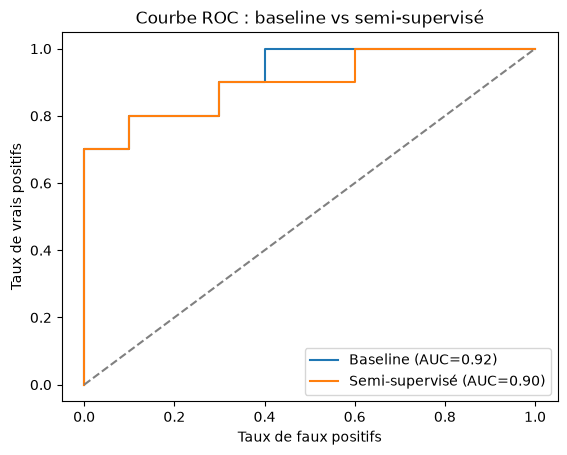

In [134]:
fpr_baseline, tpr_baseline, _ = roc_curve(vrais_labels_baseline, probabilites_baseline)
auc_baseline = roc_auc_score(vrais_labels_baseline, probabilites_baseline)

fpr_ss, tpr_ss, _ = roc_curve(vrais_labels_ss, probabilites_ss)
auc_ss = roc_auc_score(vrais_labels_ss, probabilites_ss)

plt.plot(fpr_baseline, tpr_baseline, label=f'Baseline (AUC={auc_baseline:.2f})')
plt.plot(fpr_ss, tpr_ss, label=f'Semi-supervisé (AUC={auc_ss:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # ligne de référence aléatoire
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.legend()
plt.title('Courbe ROC : baseline vs semi-supervisé')
plt.show()

### 3.3. Synthèse

Les métriques ne convergent pas toutes dans le même sens, et c'est un résultat instructif en soi. L'AUC est légèrement supérieure pour la baseline (0,92 contre 0,90), ce qui indique une capacité de classement théorique comparable, voire légèrement meilleure, sur l'ensemble des seuils de décision possibles.

En revanche, au seuil de décision réellement utilisé (0,5), l'écart est massif : la baseline ne détecte que 10 % des cancers (recall 0,10) contre 60 % pour le modèle semi-supervisé (recall 0,60), et son F1 score sur la classe cancer chute à 0,18 contre 0,75. La baseline a donc une bonne capacité de classement en théorie, mais un seuil de décision mal calibré en pratique, probablement lié aux 80 images d'entraînement insuffisantes pour apprendre une frontière de décision fiable.

Cette lecture combinée renforce l'argument central : le volume apporté par la labellisation faible (1406 images, ARI = 0,285) ne se voit pas nécessairement sur une métrique de classement pur comme l'AUC, mais il se traduit directement en décisions cliniques utilisables au seuil standard, ce qui est le critère qui compte pour un usage réel en dépistage.

À noter également : les valeurs absolues d'accuracy diffèrent de celles obtenues en session précédente (55 %/80 % ici contre 65 %/90 % alors), cohérent avec l'absence de graine fixée sur l'entraînement du fine-tuning. L'écart entre les deux modèles reste néanmoins stable à 25 points d'accuracy dans les deux exécutions.